In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("dataset/babies.csv")

In [6]:
df.head()


,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [7]:
df.describe()


,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [8]:
df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [11]:
df.drop(columns=["case"],inplace = True)

Text(0.5, 1.0, 'Gestation vs Birth Weight')

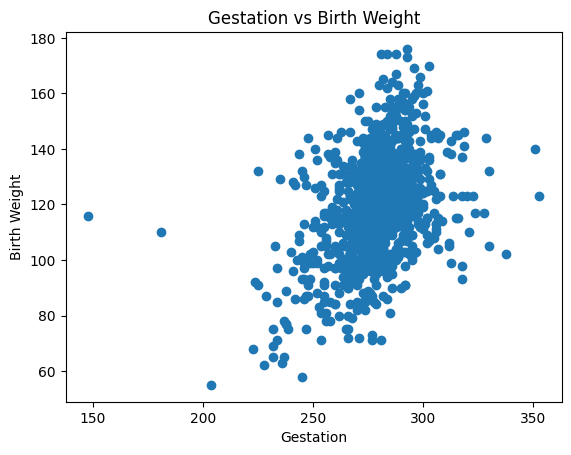

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df["gestation"], df["bwt"])

plt.xlabel("Gestation")
plt.ylabel("Birth Weight")
plt.title("Gestation vs Birth Weight")


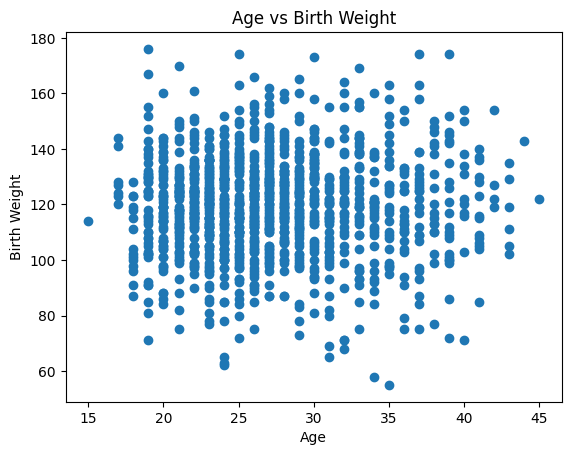

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df["age"], df["bwt"])

plt.xlabel("Age")
plt.ylabel("Birth Weight")
plt.title("Age vs Birth Weight")

plt.show()

In [17]:
y = df["bwt"]
x = df.iloc[:,1:]
x

,gestation,parity,age,height,weight,smoke
0,284.0,0,27.0,62.0,100.0,0.0
1,282.0,0,33.0,64.0,135.0,0.0
2,279.0,0,28.0,64.0,115.0,1.0
4,282.0,0,23.0,67.0,125.0,1.0
5,286.0,0,25.0,62.0,93.0,0.0
...,...,...,...,...,...,...
1231,275.0,1,27.0,60.0,100.0,0.0
1232,265.0,0,24.0,67.0,120.0,0.0
1233,291.0,0,30.0,65.0,150.0,1.0
1234,281.0,1,21.0,65.0,110.0,0.0


In [20]:
from sklearn.model_selection import  train_test_split as tts
x_train, x_test, y_train_, y_test = tts(x,y,test_size=0.20)

x_train.shape



(939, 6)

In [21]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

lr =LinearRegression()
la = Lasso()
ri = Ridge()

In [22]:
lr.fit(x_train,y_train_)
la.fit(x_train,y_train_)
ri.fit(x_train,y_train_)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [23]:
lr_pred = lr.predict(x_test)
la_pred = la.predict(x_test)
ri_pred = ri.predict(x_test)



In [24]:
from sklearn.metrics import r2_score,mean_squared_error
lr_score = r2_score(y_test,lr_pred)
la_score = r2_score(y_test,la_pred)
ri_score = r2_score(y_test,ri_pred)

In [25]:
lr_mse = mean_squared_error(y_test,lr_pred)
la_mse = mean_squared_error(y_test,la_pred)
ri_mse = mean_squared_error(y_test,ri_pred)

In [26]:
print("result of linear rig")
print("score",lr_score)
print("mse",lr_mse)



result of linear rig
score 0.2203160034808025
mse 240.94083579996746


In [27]:
print("result of lasso rig")
print("score",la_score)
print("mse",la_mse)



result of lasso rig
score 0.2058699608109955
mse 245.40500539996464


In [28]:
print("result  rig")
print("score",ri_score)
print("mse",ri_mse)



result  rig
score 0.22038980182255397
mse 240.91803036312172


In [29]:
import pickle
with open("model/model.pkl","wb") as f:
    pickle.dump(lr,f)

In [34]:
with open("model/model.pkl","rb") as f:
    model2 = pickle.load(f)
print(model2)

LinearRegression()


In [35]:
test_data = {
    "gestation":270.0,
    "parity":0,
    "age":35.0,
    "height":65.0,
    "width":135.0,
    "smoke":1.0
}
test_data

{'gestation': 270.0,
 'parity': 0,
 'age': 35.0,
 'height': 65.0,
 'width': 135.0,
 'smoke': 1.0}

In [1]:
import pandas as pd

test_data = {
    "gestation": [270.0],
    "parity": [0],
    "age": [35.0],
    "height": [65.0],
    "weight": [135.0],
    "smoke": [1.0]
}

t1 = pd.DataFrame(test_data)

print(t1)

   gestation  parity   age  height  weight  smoke
0      270.0       0  35.0    65.0   135.0    1.0


In [43]:
res = model2.predict(t1)

print(res)

[112.18807369]
